In [11]:
%reset -f
import pandas as pd
df_manuscript = pd.read_excel("/Users/lingyi/Documents/spatial/colocalization/MI_lists/dataset_in_manuscript.xlsx")

df_filter_high_aCAF = df_manuscript
selected_samples = ['CID4465_spatial', 'SN124_A938797_Rep2', 'HT232P1H2A2', 'GSM7498813_SS1945070_processed']
df_filter_high_aCAF = df_filter_high_aCAF[df_filter_high_aCAF['SampleID'].isin(selected_samples)]
df_filter_high_aCAF

,SampleID,dataset_name,label,cancer_type,COL11A1_pct_gt1,APOD_pct_gt1,LUM_pct_gt1,TREM2_pct_gt1,MS4A1_pct_gt1,CCL19_pct_gt1,...,KRT8_pct_gt1,KRT18_pct_gt1,KRT19_pct_gt1,CD3D_pct_gt1,AIF1_pct_gt1,aCAF_metagene_pct_gt1,ASC_metagene_pct_gt1,Immune_metagene_pct_gt1,Tumor_metagene_pct_gt1,Total_spots
3,CID4465_spatial,GSE176078_breast_wu/raw/zenodo/spatial,Wu,BC,57.04,13.91,99.25,11.51,4.47,17.88,...,79.39,46.36,93.05,10.10,51.90,25.50,8.11,0.00,29.97,1208
66,SN124_A938797_Rep2,Valdeolivas_colon_spatial,Valdeolivas,CRC,35.97,13.22,97.89,5.73,3.98,15.15,...,98.25,94.45,88.53,16.78,32.11,26.49,6.28,0.06,79.06,1657
95,HT232P1H2A2,HTAN_WUSTL/scRNA_vali/raw_spatial,Cui,PDAC,56.14,49.03,98.39,10.66,0.00,0.65,...,86.88,80.90,88.46,1.33,22.71,44.24,7.95,0.00,39.25,3985
109,GSM7498813_SS1945070_processed,GSE235315_PDAC,Kim,PDAC,37.73,17.65,70.46,3.59,2.24,18.66,...,96.92,93.49,NaN,2.95,3.36,11.75,4.12,0.00,68.34,3933


In [12]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import sys
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")

import tools
importlib.reload(tools)



<module 'tools' from '/Users/lingyi/Documents/spatial/colocalization/functions/tools.py'>

In [13]:
# ============= CONFIGURATION SECTION =============
# Cell population: Always use STROMAL cells (identified by LUM expression)
STROMAL_MARKER = "LUM"  # Marker to identify stromal/fibroblast clusters
Z_THRESHOLD = 0.5  # Threshold for identifying high-expressing clusters
# ==================================================
def identify_clusters_by_expression(adata, genes, z_threshold=0.5):
    """
    Identify clusters highly expressing given gene(s) using z-score thresholding.
    If multiple genes provided, uses average expression.
    Returns clusters with expression > mean + z_threshold * std.
    """
    if isinstance(genes, str):
        genes = [genes]
    
    cluster_means = {}
    
    for cluster in adata.obs['clusters'].unique():
        mask = adata.obs['clusters'] == cluster
        
        # Calculate mean expression across all provided genes
        cluster_expr_values = []
        for gene in genes:
            if gene in adata.var_names:
                expr = adata[mask, gene].X
                if hasattr(expr, "toarray"):
                    expr = expr.toarray()
                expr = np.array(expr).flatten()
                cluster_expr_values.append(np.mean(expr))
        
        # Average across genes
        if len(cluster_expr_values) > 0:
            cluster_means[cluster] = np.mean(cluster_expr_values)
        else:
            cluster_means[cluster] = 0

    # Convert to array for stats
    means = np.array(list(cluster_means.values()))
    mean_all = np.mean(means)
    std_all = np.std(means)

    # Choose clusters above threshold
    high_clusters = [c for c, m in cluster_means.items() if m > (mean_all + z_threshold * std_all)]

    gene_str = ", ".join(genes)
    print(f"\n=== {gene_str} Expression Cluster Scan ===")
    print(f"Cluster Mean Expressions: {cluster_means}")
    print(f"Mean: {mean_all:.3f} | Std: {std_all:.3f} | Threshold: {mean_all + z_threshold*std_all:.3f}")
    print(f"High {gene_str} clusters: {high_clusters}")

    return high_clusters

def calculate_signature_score(adata, gene_list, score_name):
    """Calculate signature score as mean expression of genes in the list"""
    if isinstance(gene_list, str):
        gene_list = [gene_list]
    
    # Use scanpy's built-in subsetting to safely handle gene selection
    present_genes = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(present_genes) == 0:
        raise ValueError(f"None of the genes in {gene_list} found in the dataset")
    
    # Use adata subsetting which handles duplicate gene names properly
    adata_subset = adata[:, present_genes]
    signature_expr = adata_subset.X
    
    if hasattr(signature_expr, 'toarray'):
        signature_expr = signature_expr.toarray()
    
    # Calculate mean across genes (axis=1 for mean across genes for each cell)
    signature_score = np.mean(signature_expr, axis=1)
    adata.obs[score_name] = signature_score
    
    return signature_score

def analyze_stromal_expression_by_tumor_proximity_annotation(adata, radius=200):
    """
    Analyze expression of specified genes in stromal cells based on distance to tumor.
    Returns expression scores in stromal cells near vs far from tumor, and their distances.
    """
    coords = adata.obsm['spatial_um']
    
    # Get tumor spot indices
    tumor_indices = np.where(adata.obs['annotation_tumor'])[0]
    tumor_coords = coords[tumor_indices]

    # For each spot, calculate distance to nearest tumor
    all_distances_to_tumor = []
    for i, coord in enumerate(coords):
        if len(tumor_coords) > 0:
            distances_to_tumors = np.sqrt(np.sum((tumor_coords - coord)**2, axis=1))
            min_distance = np.min(distances_to_tumors)
        else:
            min_distance = np.inf
        all_distances_to_tumor.append(min_distance)
    all_distances_to_tumor = np.array(all_distances_to_tumor)
    
    # Define masks - focus on stromal cells only
    stromal_mask = adata.obs['annotation_stromal'].values
    tumor_mask = adata.obs['annotation_tumor'].values
    other_cells_mask = ~(stromal_mask | tumor_mask)

    # Stromal cells near vs far from tumor
    stromal_near_tumor_mask = stromal_mask & (all_distances_to_tumor <= radius)
    stromal_far_tumor_mask = stromal_mask & (all_distances_to_tumor > radius)
    
    stromal_scores_near_tumor = adata.obs.loc[stromal_near_tumor_mask, 'expression_score'].values
    stromal_scores_far_tumor = adata.obs.loc[stromal_far_tumor_mask, 'expression_score'].values
    
    # compute for ALL OTHER (non-stromal, non-tumor) spots
    other_near_tumor_mask = other_cells_mask & (all_distances_to_tumor <= radius)
    other_far_tumor_mask = other_cells_mask & (all_distances_to_tumor > radius)

    other_scores_near_tumor = adata.obs.loc[other_near_tumor_mask, 'expression_score'].values
    other_scores_far_tumor = adata.obs.loc[other_far_tumor_mask, 'expression_score'].values
    
    # Get distances and stromal expression scores
    stromal_distances = all_distances_to_tumor[stromal_mask]
    stromal_scores = adata.obs.loc[stromal_mask, 'expression_score'].values
    
    return (stromal_scores_near_tumor, stromal_scores_far_tumor, 
            other_scores_near_tumor, other_scores_far_tumor, 
            stromal_distances, stromal_scores)



Processing 4 samples for 8 markers...
Each sample will be loaded once and all marker scores will be calculated from that loaded sample.

Sample: CID4465_spatial
Dataset: GSE176078_breast_wu/raw/zenodo/spatial
  Loading data from: /Volumes/T7/datasets/GSE176078_breast_wu/raw/zenodo/spatial/raw/CID4465_spatial


/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:175: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",


Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/GSE176078_breast_wu/raw/zenodo/spatial/raw/CID4465_spatial
→ Computed microns_per_pixel = 0.7745 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 2.9600063159779015, '1': 2.8415062910072697, '2': 2.2181270420998134, '3': 2.4631991964539046, '4': 2.0197443340071306, '5': 3.2201980711159024, '6': 3.064169488674342, '7': 2.7352421217904337, '8': 2.9286082045589796, '9': 2.5147623980585583, '10': 2.2476333438967577}
Mean: 2.656 | Std: 0.371 | Threshold: 2.841
High LUM clusters: ['0', '1', '5', '6', '8']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 0.4029129362533097, '1': 0.2622298536881356, '2': 1.5481393079067216, '3': 0.4622667547002688, '4': 1.3758981524413205, '5': 0.8355494866797623, '6': 1.372911905461695, '7': 1.0286211461473327, '8': 0.6855443682716069, '9': 0.9944920989531576, '10': 0.3768817191280867

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:175: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/Valdeolivas_colon_spatial/raw/SN124_A938797_Rep2
→ Computed microns_per_pixel = 3.2948 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 3.7968013, '1': 2.1418939, '2': 2.9910405, '3': 3.361543, '4': 4.1534805, '5': 3.4887345, '6': 2.0814989, '7': 1.5995343, '8': 3.2667835, '9': 3.385928, '10': 1.7905256, '11': 3.938808, '12': 3.168757}
Mean: 3.013 | Std: 0.807 | Threshold: 3.416
High LUM clusters: ['0', '4', '5', '11']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 2.213652, '1': 3.0414379, '2': 2.7813964, '3': 2.0244744, '4': 1.526521, '5': 1.0754919, '6': 2.9151957, '7': 3.341742, '8': 1.956903, '9': 2.2312248, '10': 2.9294548, '11': 1.6516938, '12': 1.2314599}
Mean: 2.225 | Std: 0.703 | Threshold: 2.576
High EPCAM clusters: ['1', '2', '6', '7', '10']
    Processing aCAF markers...
    Processing T cell mar

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:198: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(


Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/HTAN_WUSTL/scRNA_vali/raw_spatial/raw/HT232P1H2A2 (no hires image)
→ Computed microns_per_pixel = 0.3030 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.
Filtered off-tissue spots: kept 4067 / 4992
Added lowres image, scalefactors, and spatial coords manually.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 2.521775545007566, '2': 2.7125152604852585, '3': 2.9094698247383852, '5': 2.095009649442896, '6': 2.908196942692797, '1': 2.46242697680553, '4': 2.876642502887282, '7': 3.3187710310486054, '8': 1.7066529670956931, '9': 3.323739760295301, '10': 3.3636575449084027, '11': 3.1431130169066805, '12': 2.6234172922003554, '13': 3.029203388387897, '14': 1.2230956123638057}
Mean: 2.681 | Std: 0.592 | Threshold: 2.977
High LUM clusters: ['7', '9', '10', '11', '13']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.3384032593791235, '2': 0.8464711056563388, '3': 0.5

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:175: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/GSE235315_PDAC/raw/GSM7498813_SS1945070_processed
→ Computed microns_per_pixel = 0.1223 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.1279892, '1': 1.1520574, '3': 1.7172403, '4': 1.7798758, '2': 1.8701175, '6': 1.2416083, '7': 1.3105518, '8': 0.6902207, '9': 1.1677821, '10': 1.3905871, '12': 0.94827634, '5': 0.9343482, '11': 1.3618596}
Mean: 1.284 | Std: 0.333 | Threshold: 1.450
High LUM clusters: ['3', '4', '2']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.4765425, '1': 0.9589088, '3': 0.89637196, '4': 1.1563543, '2': 0.7460912, '6': 1.5751039, '7': 1.3536664, '8': 0.42390478, '9': 1.575146, '10': 1.2765585, '12': 1.4646636, '5': 1.5359619, '11': 1.2254652}
Mean: 1.205 | Std: 0.343 | Threshold: 1.377
High EPCAM clusters: ['0', '6', '9', '12', '5']
    Processing aCAF markers...
    Processing T cel

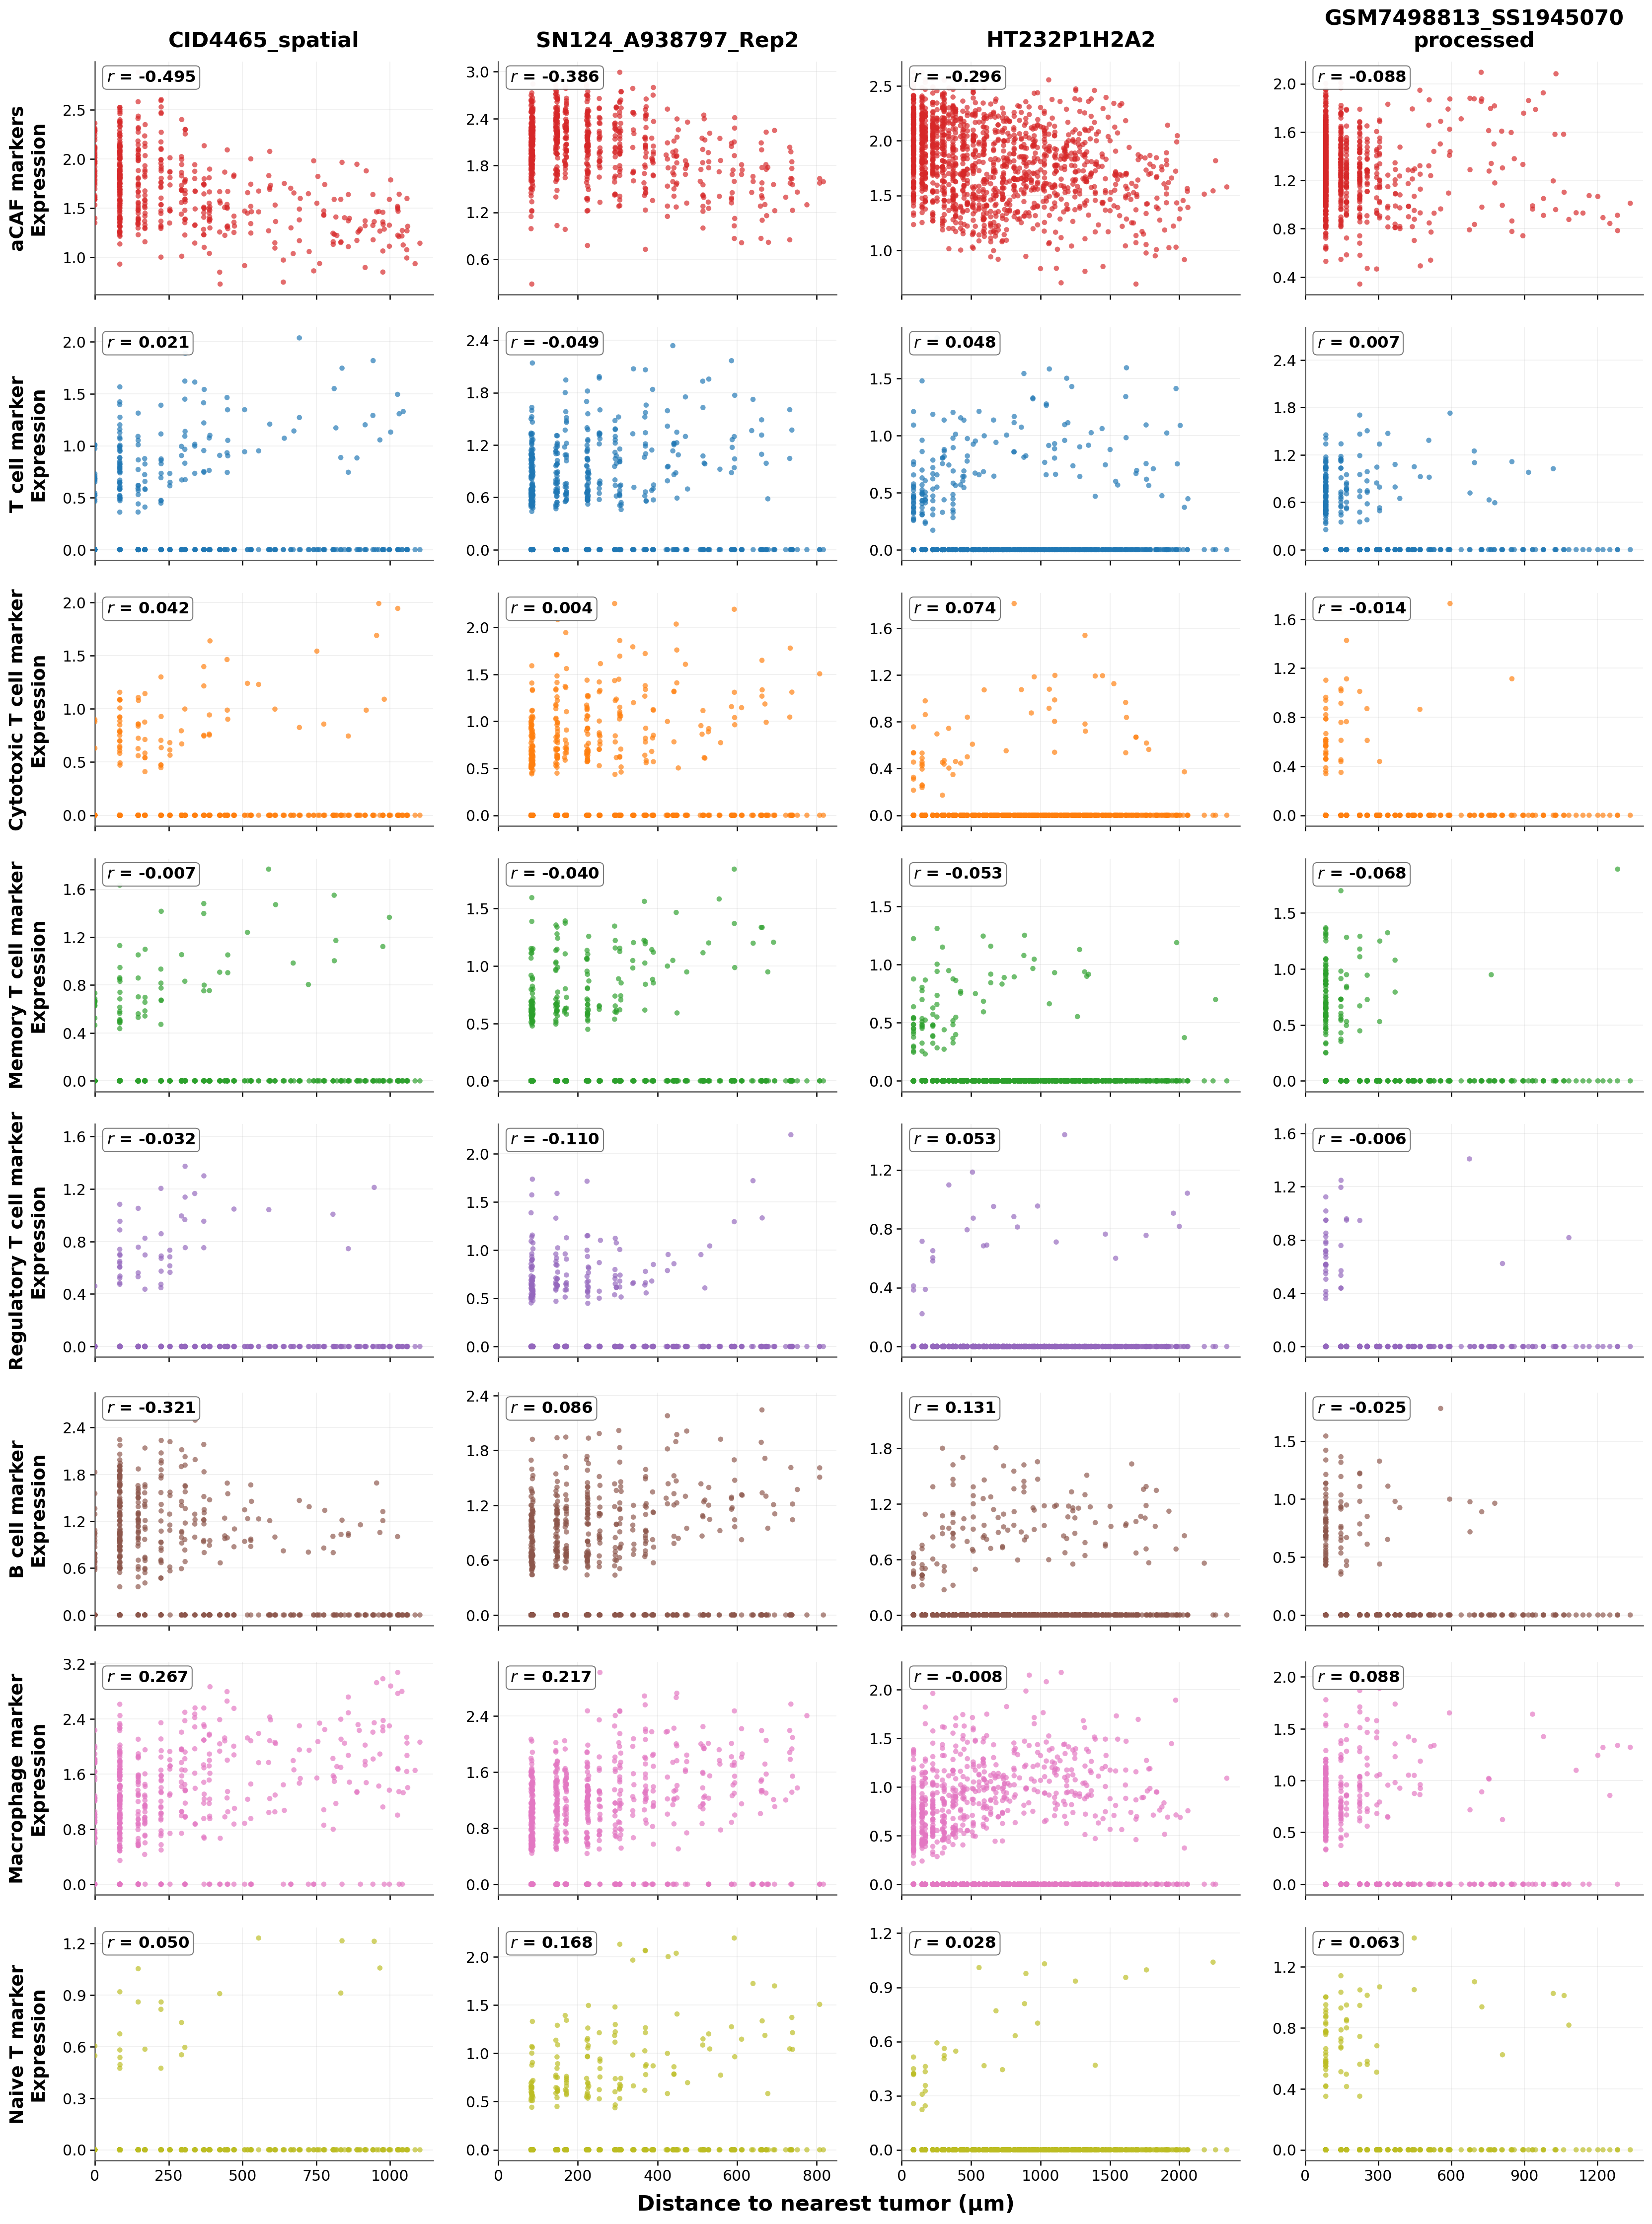

In [14]:
# =====================================================================
# MULTI-MARKER SPATIAL ANALYSIS
# One figure, eight marker rows, improved readability
# =====================================================================

import textwrap
import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial import cKDTree
from matplotlib.ticker import MaxNLocator


# =====================================================================
# MULTI-MARKER ANALYSIS CONFIGURATION
# =====================================================================

MARKER_CONFIGS = [
    {
        "label": "aCAF markers",
        "genes": [
            "COL11A1", "THBS2", "COL10A1", "COL5A2", "INHBA",
            "LRRC15", "COL5A1", "VCAN", "FAP", "COL1A1"
        ],
        "color": "#d62728"
    },
    {
        "label": "T cell marker",
        "genes": ["CD3D"],
        "color": "#1f77b4"
    },
    {
        "label": "Cytotoxic T cell marker",
        "genes": ["CD8A"],
        "color": "#ff7f0e"
    },
    {
        "label": "Memory T cell marker",
        "genes": ["TCF7"],
        "color": "#2ca02c"
    },
    {
        "label": "Regulatory T cell marker",
        "genes": ["FOXP3"],
        "color": "#9467bd"
    },
    {
        "label": "B cell marker",
        "genes": ["CD79A"],
        "color": "#8c564b"
    },
    {
        "label": "Macrophage marker",
        "genes": ["CD163"],
        "color": "#e377c2"
    },
    {
        "label": "Naive T marker",
        "genes": ["CCR7"],
        "color": "#bcbd22"
    }
]


# =====================================================================
# HELPER FUNCTIONS
# =====================================================================

def format_sample_title(sample_id, max_characters=24):
    """
    Wrap long sample names at underscores so that column titles remain
    readable without overlapping neighboring panels.
    """
    sample_id = str(sample_id)

    if len(sample_id) <= max_characters:
        return sample_id

    components = sample_id.split("_")

    if len(components) == 1:
        return textwrap.fill(sample_id, width=max_characters)

    lines = []
    current_line = components[0]

    for component in components[1:]:
        candidate = f"{current_line}_{component}"

        if len(candidate) <= max_characters:
            current_line = candidate
        else:
            lines.append(current_line)
            current_line = component

    lines.append(current_line)

    return "\n".join(lines)


def calculate_correlations(distances, scores):
    """
    Calculate Pearson and Spearman correlations after removing nonfinite
    values. Returns NaN when there are too few observations or when either
    variable is constant.
    """
    distances = np.asarray(distances, dtype=float).ravel()
    scores = np.asarray(scores, dtype=float).ravel()

    valid_mask = np.isfinite(distances) & np.isfinite(scores)

    distances = distances[valid_mask]
    scores = scores[valid_mask]

    if len(distances) < 2:
        return np.nan, np.nan, np.nan, np.nan

    if np.ptp(distances) == 0 or np.ptp(scores) == 0:
        return np.nan, np.nan, np.nan, np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        pearson_r, pearson_p = stats.pearsonr(
            distances,
            scores
        )

        spearman_r, spearman_p = stats.spearmanr(
            distances,
            scores
        )

    return pearson_r, pearson_p, spearman_r, spearman_p


# =====================================================================
# PROCESS A SINGLE SAMPLE
# =====================================================================

def process_single_sample(
    dataset_name,
    sample_id,
    base_folder="/Volumes/T7/datasets"
):
    """
    Load one spatial sample and calculate all marker scores.

    The sample is loaded only once. Tumor/stromal annotation and distance
    calculations are also performed only once.

    Returns
    -------
    list of dict
        One result dictionary for each marker configuration.
    """

    folder = f"{base_folder}/{dataset_name}/raw/{sample_id}"

    try:
        print(f"  Loading data from: {folder}")

        # -------------------------------------------------------------
        # Load and preprocess the spatial sample
        # -------------------------------------------------------------

        proc = tools.spatialTool()

        adata = proc.dataprocess(
            folder,
            skip_qc=False,
            verbose=False
        )

        # -------------------------------------------------------------
        # Identify stromal and epithelial/tumor clusters
        # -------------------------------------------------------------

        stromal_clusters = identify_clusters_by_expression(
            adata,
            STROMAL_MARKER,
            z_threshold=Z_THRESHOLD
        )

        epithelial_clusters = identify_clusters_by_expression(
            adata,
            "EPCAM",
            z_threshold=0.5
        )

        epithelial_spots = adata.obs["clusters"].isin(
            epithelial_clusters
        )

        stromal_spots = adata.obs["clusters"].isin(
            stromal_clusters
        )

        adata.obs["annotation_tumor"] = epithelial_spots
        adata.obs["annotation_stromal"] = stromal_spots

        # -------------------------------------------------------------
        # Obtain spatial coordinates
        # -------------------------------------------------------------

        coordinates = np.asarray(
            adata.obsm["spatial_um"],
            dtype=float
        )

        tumor_mask = adata.obs[
            "annotation_tumor"
        ].to_numpy(dtype=bool)

        stromal_mask = adata.obs[
            "annotation_stromal"
        ].to_numpy(dtype=bool)

        tumor_coordinates = coordinates[tumor_mask]

        # -------------------------------------------------------------
        # Calculate distance to the nearest tumor location
        # -------------------------------------------------------------

        if len(tumor_coordinates) > 0:
            tumor_tree = cKDTree(tumor_coordinates)

            all_distances_to_tumor, _ = tumor_tree.query(
                coordinates,
                k=1
            )
        else:
            print(
                f"  Warning: No tumor spots identified for {sample_id}."
            )

            all_distances_to_tumor = np.full(
                coordinates.shape[0],
                np.nan,
                dtype=float
            )

        stromal_distances = np.asarray(
            all_distances_to_tumor[stromal_mask],
            dtype=float
        )

        # -------------------------------------------------------------
        # Calculate each marker score
        # -------------------------------------------------------------

        results_for_sample = []

        for marker_config in MARKER_CONFIGS:
            marker_label = marker_config["label"]
            requested_genes = marker_config["genes"]

            print(f"    Processing {marker_label}...")

            present_genes = [
                gene
                for gene in requested_genes
                if gene in adata.var_names
            ]

            missing_genes = [
                gene
                for gene in requested_genes
                if gene not in adata.var_names
            ]

            if missing_genes:
                print(
                    "      Missing genes: "
                    + ", ".join(missing_genes)
                )

            if len(present_genes) == 0:
                print(
                    f"      Warning: No genes found for {marker_label}."
                )

                results_for_sample.append({
                    "dataset": dataset_name,
                    "sample": sample_id,
                    "marker_label": marker_label,
                    "stromal_distances": np.array([]),
                    "stromal_scores": np.array([]),
                    "pearson_r": np.nan,
                    "pearson_p": np.nan,
                    "spearman_r": np.nan,
                    "spearman_p": np.nan,
                    "n_stromal": 0,
                    "genes_used": []
                })

                continue

            # Extract expression for available genes.
            marker_expression = adata[:, present_genes].X

            if hasattr(marker_expression, "toarray"):
                marker_expression = marker_expression.toarray()
            else:
                marker_expression = np.asarray(marker_expression)

            # Mean expression across the genes in this marker set.
            marker_scores = np.asarray(
                marker_expression.mean(axis=1)
            ).ravel()

            stromal_scores = np.asarray(
                marker_scores[stromal_mask],
                dtype=float
            )

            # Remove nonfinite observations before storing or plotting.
            valid_mask = (
                np.isfinite(stromal_distances)
                & np.isfinite(stromal_scores)
            )

            valid_distances = stromal_distances[valid_mask]
            valid_scores = stromal_scores[valid_mask]

            (
                pearson_r,
                pearson_p,
                spearman_r,
                spearman_p
            ) = calculate_correlations(
                valid_distances,
                valid_scores
            )

            results_for_sample.append({
                "dataset": dataset_name,
                "sample": sample_id,
                "marker_label": marker_label,
                "stromal_distances": valid_distances,
                "stromal_scores": valid_scores,
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
                "n_stromal": len(valid_distances),
                "genes_used": present_genes
            })

        return results_for_sample

    except Exception as error:
        print(
            f"  Error processing {dataset_name}/{sample_id}: "
            f"{error}"
        )

        return []


# =====================================================================
# CREATE ONE FIGURE WITH ALL EIGHT MARKER ROWS
# =====================================================================

def create_multi_marker_plot(results_list, samples_list):
    """
    Create one figure with markers as rows and samples as columns.

    Readability improvements:
      - all eight marker rows remain in one figure;
      - long sample names are wrapped;
      - repeated x-axis titles are replaced by one shared title;
      - x tick labels are displayed only on the bottom row;
      - marker names appear only in the first column;
      - correlation annotations use larger text and opaque backgrounds;
      - tick density is limited;
      - the x-axis scale is consistent within each sample column;
      - unnecessary top and right plot borders are removed.
    """

    n_markers = len(MARKER_CONFIGS)
    n_samples = len(samples_list)

    if n_samples == 0:
        raise ValueError("samples_list is empty.")

    # A large single figure is necessary for an eight-row layout.
    figure_width = max(16.0, 4.6 * n_samples)
    figure_height = max(24.0, 3.1 * n_markers)

    fig, axes = plt.subplots(
        nrows=n_markers,
        ncols=n_samples,
        figsize=(figure_width, figure_height),
        dpi=180,
        squeeze=False,
        constrained_layout=True
    )

    fig.set_constrained_layout_pads(
        w_pad=0.06,
        h_pad=0.06,
        wspace=0.08,
        hspace=0.10
    )

    # Build a result lookup table to avoid repeatedly scanning the list.
    result_lookup = {
        (result["sample"], result["marker_label"]): result
        for result in results_list
    }

    # -------------------------------------------------------------
    # Determine a common x-axis limit for each sample column
    # -------------------------------------------------------------

    sample_x_limits = {}

    for sample_id in samples_list:
        sample_distances = []

        for marker_config in MARKER_CONFIGS:
            result = result_lookup.get(
                (sample_id, marker_config["label"])
            )

            if result is None:
                continue

            distances = np.asarray(
                result["stromal_distances"],
                dtype=float
            )

            distances = distances[np.isfinite(distances)]

            if len(distances) > 0:
                sample_distances.append(distances)

        if sample_distances:
            maximum_distance = np.max(
                np.concatenate(sample_distances)
            )

            # Leave a small amount of space at the right edge.
            sample_x_limits[sample_id] = max(
                1.0,
                maximum_distance * 1.04
            )
        else:
            sample_x_limits[sample_id] = 1.0

    # -------------------------------------------------------------
    # Draw every marker/sample panel
    # -------------------------------------------------------------

    for marker_index, marker_config in enumerate(MARKER_CONFIGS):
        marker_label = marker_config["label"]
        marker_color = marker_config["color"]

        for sample_index, sample_id in enumerate(samples_list):
            ax = axes[marker_index, sample_index]

            result = result_lookup.get(
                (sample_id, marker_label)
            )

            has_data = (
                result is not None
                and len(result["stromal_distances"]) > 0
                and len(result["stromal_scores"]) > 0
            )

            if has_data:
                distances = np.asarray(
                    result["stromal_distances"],
                    dtype=float
                )

                scores = np.asarray(
                    result["stromal_scores"],
                    dtype=float
                )

                ax.scatter(
                    distances,
                    scores,
                    s=18,
                    alpha=0.68,
                    color=marker_color,
                    edgecolors="none",
                    zorder=3
                )

                pearson_r = result["pearson_r"]

                if np.isfinite(pearson_r):
                    correlation_text = (
                        rf"$r$ = {pearson_r:.3f}"
                    )
                else:
                    correlation_text = r"$r$ = NA"

                ax.text(
                    0.035,
                    0.965,
                    correlation_text,
                    transform=ax.transAxes,
                    horizontalalignment="left",
                    verticalalignment="top",
                    fontsize=13,
                    fontweight="semibold",
                    zorder=10,
                    bbox={
                        "boxstyle": "round,pad=0.25",
                        "facecolor": "white",
                        "edgecolor": "0.45",
                        "linewidth": 0.8,
                        "alpha": 0.96
                    }
                )

            else:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    transform=ax.transAxes,
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=14,
                    fontweight="semibold",
                    color="0.45"
                )

            # Use the same x range for every marker in a sample column.
            ax.set_xlim(
                0,
                sample_x_limits[sample_id]
            )

            # Prevent excessive tick-label density.
            ax.xaxis.set_major_locator(
                MaxNLocator(
                    nbins=5,
                    min_n_ticks=3
                )
            )

            ax.yaxis.set_major_locator(
                MaxNLocator(
                    nbins=5,
                    min_n_ticks=3
                )
            )

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=12,
                width=1.0,
                length=4,
                pad=3
            )

            # Only display x tick labels on the final row.
            if marker_index != n_markers - 1:
                ax.tick_params(
                    axis="x",
                    labelbottom=False
                )

            ax.grid(
                visible=True,
                which="major",
                linewidth=0.6,
                alpha=0.22,
                zorder=0
            )

            # Simplify the panel borders.
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.spines["left"].set_linewidth(1.0)
            ax.spines["bottom"].set_linewidth(1.0)

            ax.spines["left"].set_color("0.35")
            ax.spines["bottom"].set_color("0.35")

            # Sample titles appear only above the first row.
            if marker_index == 0:
                ax.set_title(
                    format_sample_title(sample_id),
                    fontsize=17,
                    fontweight="bold",
                    linespacing=1.05,
                    pad=12
                )

            # Marker labels appear only beside the first column.
            if sample_index == 0:
                ax.set_ylabel(
                    f"{marker_label}\nExpression",
                    fontsize=15,
                    fontweight="bold",
                    labelpad=12
                )
            else:
                ax.set_ylabel("")

            # Remove individual x-axis labels.
            ax.set_xlabel("")

    # One shared x-axis label replaces 32 repeated labels.
    fig.supxlabel(
        "Distance to nearest tumor (µm)",
        fontsize=17,
        fontweight="bold"
    )

    return fig


# =====================================================================
# MAIN ANALYSIS
# =====================================================================

print(
    f"Processing {len(df_filter_high_aCAF)} samples "
    f"for {len(MARKER_CONFIGS)} markers..."
)

print(
    "Each sample will be loaded once and all marker scores "
    "will be calculated from that loaded sample.\n"
)

all_results_multi = []
samples_list = []

for _, row in df_filter_high_aCAF.iterrows():
    dataset_name = row["dataset_name"]
    sample_id = row["SampleID"]

    samples_list.append(sample_id)

    print("=" * 70)
    print(f"Sample: {sample_id}")
    print(f"Dataset: {dataset_name}")
    print("=" * 70)

    sample_results = process_single_sample(
        dataset_name=dataset_name,
        sample_id=sample_id
    )

    all_results_multi.extend(sample_results)

print("\n" + "=" * 70)
print("Processing complete.")
print(f"Total results: {len(all_results_multi)}")
print(f"Number of samples: {len(samples_list)}")
print(f"Number of marker groups: {len(MARKER_CONFIGS)}")
print(f"Number of data loads: {len(samples_list)}")
print("=" * 70 + "\n")


# =====================================================================
# DISPLAY ONE FIGURE
# =====================================================================

if len(all_results_multi) > 0:
    fig = create_multi_marker_plot(
        results_list=all_results_multi,
        samples_list=samples_list
    )

    plt.show()

else:
    print("No results are available to plot.")